__librerías__

In [153]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as pdr
import seaborn as sns
from statsmodels.tsa.api import acf, graphics, pacf
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
np.random.seed(42)

In [5]:
sns.set_style("darkgrid")
pd.plotting.register_matplotlib_converters()
# Default figure size
sns.mpl.rc("figure", figsize=(16, 6))
sns.mpl.rc("font", size=14)

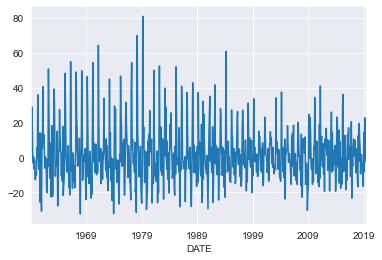

In [11]:
data = pdr.get_data_fred("HOUSTNSA", "1959-01-01", "2019-06-01")
housing = data.HOUSTNSA.pct_change().dropna()
# Scale by 100 to get percentages
housing = 100 * housing.asfreq("MS")
fig, ax = plt.subplots()
ax = housing.plot(ax=ax)

In [12]:
mod = AutoReg(housing, 3, old_names=False)
res = mod.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:               HOUSTNSA   No. Observations:                  725
Model:                     AutoReg(3)   Log Likelihood               -2993.442
Method:               Conditional MLE   S.D. of innovations             15.289
Date:                Thu, 14 Jul 2022   AIC                           5996.884
Time:                        22:07:27   BIC                           6019.794
Sample:                    05-01-1959   HQIC                          6005.727
                         - 06-01-2019                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.1228      0.573      1.961      0.050       0.000       2.245
HOUSTNSA.L1     0.1910      0.036      5.235      0.000       0.120       0.263
HOUSTNSA.L2     0.0058      0.037      0.155    

In [13]:
res = mod.fit(cov_type="HC0")
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:               HOUSTNSA   No. Observations:                  725
Model:                     AutoReg(3)   Log Likelihood               -2993.442
Method:               Conditional MLE   S.D. of innovations             15.289
Date:                Thu, 14 Jul 2022   AIC                           5996.884
Time:                        22:07:45   BIC                           6019.794
Sample:                    05-01-1959   HQIC                          6005.727
                         - 06-01-2019                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           1.1228      0.601      1.869      0.062      -0.055       2.300
HOUSTNSA.L1     0.1910      0.035      5.499      0.000       0.123       0.259
HOUSTNSA.L2     0.0058      0.039      0.150    

In [15]:
sel = ar_select_order(housing, 13, old_names=False)
sel.ar_lags
res = sel.model.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:               HOUSTNSA   No. Observations:                  725
Model:                    AutoReg(13)   Log Likelihood               -2676.157
Method:               Conditional MLE   S.D. of innovations             10.378
Date:                Thu, 14 Jul 2022   AIC                           5382.314
Time:                        22:08:02   BIC                           5450.835
Sample:                    03-01-1960   HQIC                          5408.781
                         - 06-01-2019                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.3615      0.458      2.970      0.003       0.463       2.260
HOUSTNSA.L1     -0.2900      0.036     -8.161      0.000      -0.360      -0.220
HOUSTNSA.L2     -0.0828      0.031     -2.65

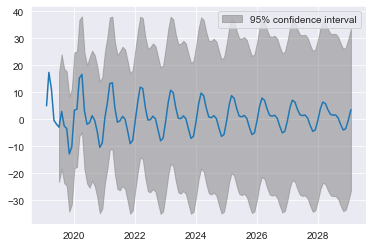

In [16]:
fig = res.plot_predict(720, 840)

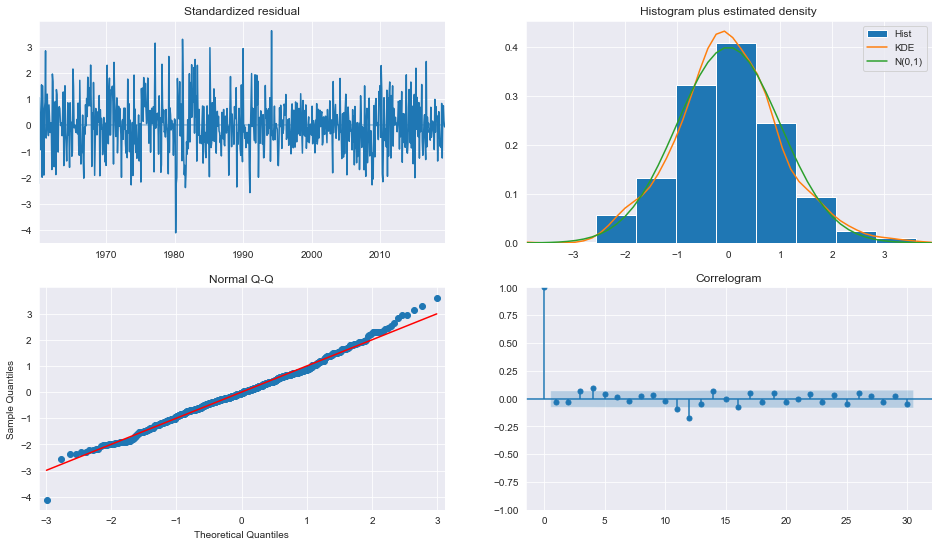

In [17]:
fig = plt.figure(figsize=(16, 9))
fig = res.plot_diagnostics(fig=fig, lags=30)

---

# GENERADOR DE PROCESOS ARMA

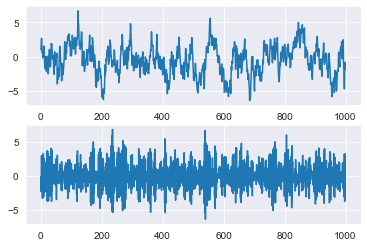

In [19]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np
# Plot 1: AR parameter = +0.9
plt.subplot(2, 1, 1)
ar1 = np.array([1, -0.9])
ma1 = np.array([1])
AR_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = AR_object1.generate_sample(nsample=1000)
plt.plot(simulated_data_1);

# Plot 2: AR parameter = -0.9
plt.subplot(2, 1, 2)
ar2 = np.array([1, 0.9])
ma2 = np.array([1])
AR_object2 = ArmaProcess(ar2, ma2)
simulated_data_2 = AR_object2.generate_sample(nsample=1000)
plt.plot(simulated_data_2);

In [33]:
# help(ArmaProcess)

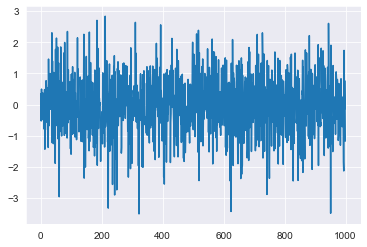

In [26]:
ar1 = np.array([1, 0.1])
ma1 = np.array([1])
AR_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = AR_object1.generate_sample(nsample=1000)
plt.plot(simulated_data_1);

__Tendencia__

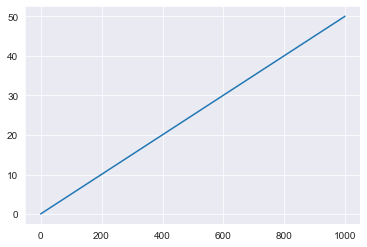

In [131]:
trend = [0.05+0.05*i for i in range(1000)]
plt.plot(trend);

__Estacionalidad__

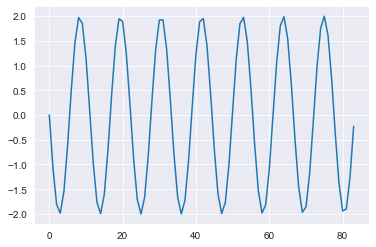

In [124]:
season = [np.sin(i)*2  for i in np.arange(0,1000,12)]
# season = [i+np.random.randn() for i in season]
plt.plot(season)

__Componente Irregular__

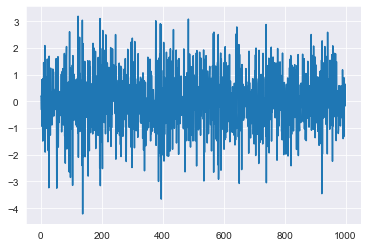

In [95]:
ar1 = np.array([1, 0.5])
ma1 = np.array([1])
AR_object1 = ArmaProcess(ar1, ma1)
simulated_data_1 = AR_object1.generate_sample(nsample=1000)
plt.plot(simulated_data_1);

__Serie Total__

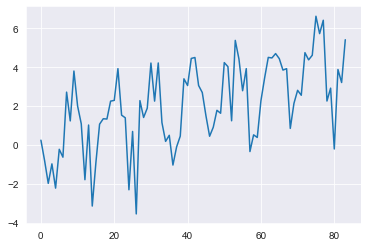

In [132]:
serie_1 = [i+j+k for i,j,k in zip(trend ,season,simulated_data_1)]
plt.plot(serie_1);

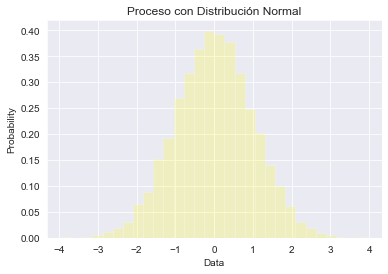

In [149]:

x = np.random.normal(size=10000)

plt.hist(x, density=True, bins=30,alpha=0.2,color='yellow')  # density=False would make counts
plt.ylabel('Probability')
plt.xlabel('Data');
plt.title('Proceso con Distribución Normal');


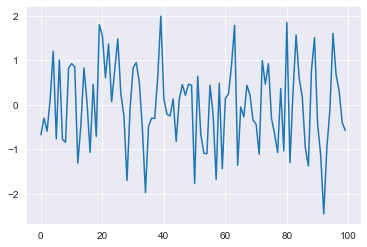

In [164]:
x = list(range(100))
y = np.random.normal(size=1000)
plt.plot(x, y)

__Histogramas__

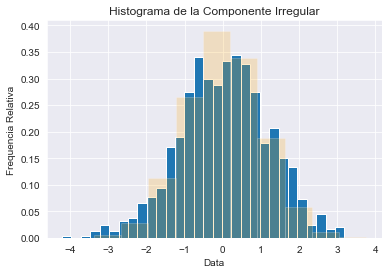

In [178]:

plt.hist(simulated_data_1, density=True, bins=30)  # density=False would make counts
plt.ylabel('Frequencia Relativa')
plt.xlabel('Data');
plt.title('Histograma de la Componente Irregular');
y = np.random.normal(size=10000)
plt.hist(y, density=True, alpha=0.2,color='orange');  # density=False would make counts

# trend ,season,simulated_data_1

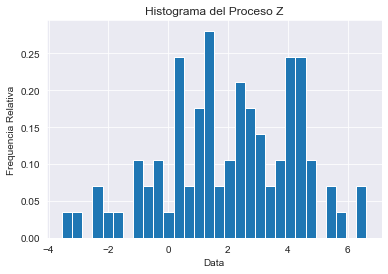

In [148]:
plt.hist(serie_1, density=True, bins=30)  # density=False would make counts
plt.ylabel('Frequencia Relativa')
plt.xlabel('Data');
plt.title('Histograma del Proceso Z');

# trend ,season,simulated_data_1

In [157]:
lista =[1+i for i in range(10)]
lista

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [161]:
lista[1:]

[2, 3, 4, 5, 6, 7, 8, 9, 10]

In [ ]:
[0.9*j if i]

Esdras 2:66 Llevaron consigo 736 caballos, 245 mulas

Esdras 2:67 435 camellos y 6720 burros.

e = 2.1718

In [193]:
(736*245)*(435*6720)

527111424000